In [1]:
# --- CÉLULA 1: IMPORTAÇÕES ---
import numpy as np
import matplotlib.pyplot as plt

# Configuração de estilo para gráficos
plt.style.use('seaborn-v0_8-whitegrid') #
plt.rcParams['figure.figsize'] = (10, 6) # Tamanho padrão dos gráficos
plt.rcParams['font.size'] = 12           # Tamanho da fonte

print("Bibliotecas importadas e estilo configurado.")

Bibliotecas importadas e estilo configurado.


In [2]:
# --- CÉLULA 2: FUNÇÕES FÍSICAS ---

def relacao_dispersao(k, R, Da, Ca, Bom, Lambda, theta_graus):
    """
    Calcula a taxa de crescimento adimensional s(k).

    A equação implementada é:
    s = k(R-1)/(R+1) + [Da*k / Ca(1+R)] * [ -k^2 + Bom*k*Lambda*cos(2*theta) ]

    Parâmetros:
    -----------
    k           : Número de onda adimensional (kL)
    R           : Razão de viscosidade (eta2 / eta1)
    Da          : Número de Darcy (Permeabilidade)
    Ca          : Número de Capilaridade (Efeito do Fluxo/Tensão Superficial)
    Bom         : Número de Bond Magnético (Força Magnética/Tensão Superficial)
    Lambda      : Coeficiente de Contraste Magnético
    theta_graus : Ângulo do campo (0=Normal/Vertical, 90=Tangencial/Horizontal)
    """
    # 1. Converter graus para radianos para funções trigonométricas
    theta = np.radians(theta_graus)

    # 2. Fator Angular Magnético
    # Derivação: (H_n^2 - H_t^2) = cos^2(theta) - sin^2(theta) = cos(2*theta)
    # Se theta=0 (Normal) -> cos(0)=1 (Desestabiliza)
    # Se theta=90 (Tangencial) -> cos(180)=-1 (Estabiliza)
    fator_angular = np.cos(2 * theta)

    # 3. Termo Viscoso (Saffman-Taylor Puro)
    # Instabilidade clássica se R > 1 (fluido mais viscoso empurrando menos viscoso)
    termo_viscoso = k * (R - 1) / (R + 1)

    # 4. Pré-fator dos termos difusivos/magnéticos
    pre_fator = (Da * k) / (Ca * (1 + R))

    # 5. Termo entre colchetes (Competição: Capilaridade vs. Magnético)
    # -k^2: Estabilização por tensão superficial (sempre negativo)
    # +Bom...: Força magnética (sinal depende do fator angular)
    termo_interno = -k**2 + (Bom * k * Lambda * fator_angular)

    # Soma final
    s = termo_viscoso + pre_fator * termo_interno
    return s

def velocidade_critica_bom(bom, k, sigma, eta_diff, K, Lambda, theta_graus):
    """
    Calcula a Velocidade Crítica Uc em função da intensidade magnética (Bo_m).

    Se U_esc > Uc, o sistema é instável.
    Se Uc < 0, o sistema sofre instabilidade estática (sem fluxo).
    """
    theta = np.radians(theta_graus)
    fator_angular = np.cos(2 * theta) # 1 para Normal, -1 para Tangencial

    # Termo Capilar (Estabilizante natural)
    termo_capilar = k**2 * sigma

    # Termo Magnético
    # Note que na derivação Uc = (K/diff) * [Capilar - Magnetico]
    # O termo magnético aqui é positivo em magnitude, o sinal vem da subtração na eq. final
    termo_magnetico = k * bom * Lambda * fator_angular

    uc = (K / eta_diff) * (termo_capilar - termo_magnetico)
    return uc

print("Funções 'relacao_dispersao' e 'velocidade_critica_bom' definidas.")

Funções 'relacao_dispersao' e 'velocidade_critica_bom' definidas.


In [3]:
# --- CÉLULA 3: PARÂMETROS BASE ---

# Vetor de números de onda (eixo X dos gráficos de dispersão)
k_vals = np.linspace(0, 15, 500)

# Parâmetros Adimensionais Fixos
R_base = 5.0      # Razão de Viscosidade (R > 1 implica instabilidade viscosa)
Da_base = 1e-4    # Número de Darcy (Meio pouco permeável)
Ca_base = 1e-2    # Número de Capilaridade (Razão Forças Viscosas/Tensão Superficial)
Lambda_base = 0.8 # Contraste Magnético (Diferença de permeabilidade entre fluidos)
Bom_base = 50.0   # Bond Magnético (Campo Forte)

print(f"Parâmetros definidos:\nR={R_base}, Da={Da_base}, Ca={Ca_base}, Bo_m={Bom_base}")

Parâmetros definidos:
R=5.0, Da=0.0001, Ca=0.01, Bo_m=50.0


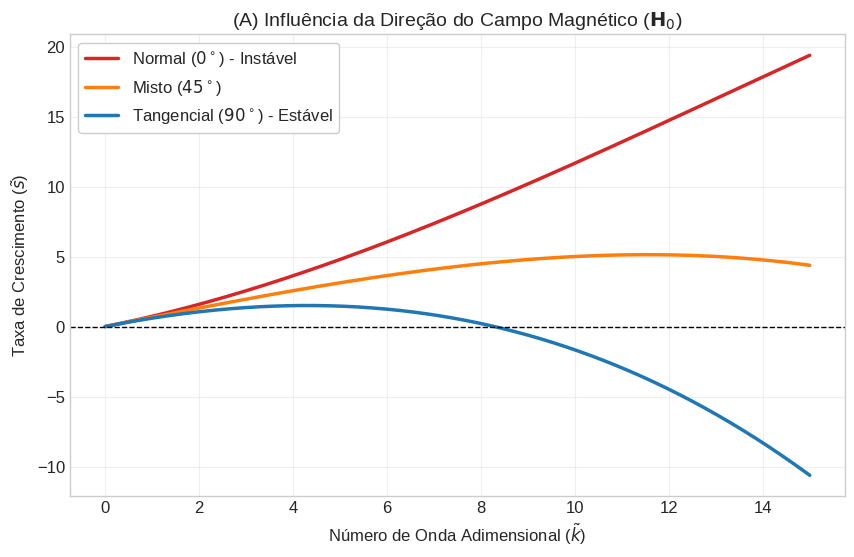

In [4]:
# --- CÉLULA 4: GRÁFICO A (ÂNGULO) ---

plt.figure(figsize=(10, 6))

# Definindo os casos a testar
angulos = [0, 45, 90]
cores = ['#d62728', '#ff7f0e', '#1f77b4'] # Vermelho, Laranja, Azul
labels = [r'Normal ($0^\circ$) - Instável', r'Misto ($45^\circ$)', r'Tangencial ($90^\circ$) - Estável']

# Loop para plotar cada curva
for ang, cor, lab in zip(angulos, cores, labels):
    # Calcula s(k) usando os parâmetros base, variando apenas o ângulo
    s = relacao_dispersao(k_vals, R_base, Da_base, Ca_base, Bom_base, Lambda_base, ang)
    plt.plot(k_vals, s, color=cor, linewidth=2.5, label=lab)

# Linha de referência (s=0)
plt.axhline(0, color='black', linewidth=1, linestyle='--')

# Decoração
plt.title(r'(A) Influência da Direção do Campo Magnético ($\mathbf{H}_0$)', fontsize=14)
plt.xlabel(r'Número de Onda Adimensional ($\tilde{k}$)', fontsize=12)
plt.ylabel(r'Taxa de Crescimento ($\tilde{s}$)', fontsize=12)
plt.legend(frameon=True, fancybox=True, framealpha=1)
plt.grid(True, alpha=0.3)

plt.show()

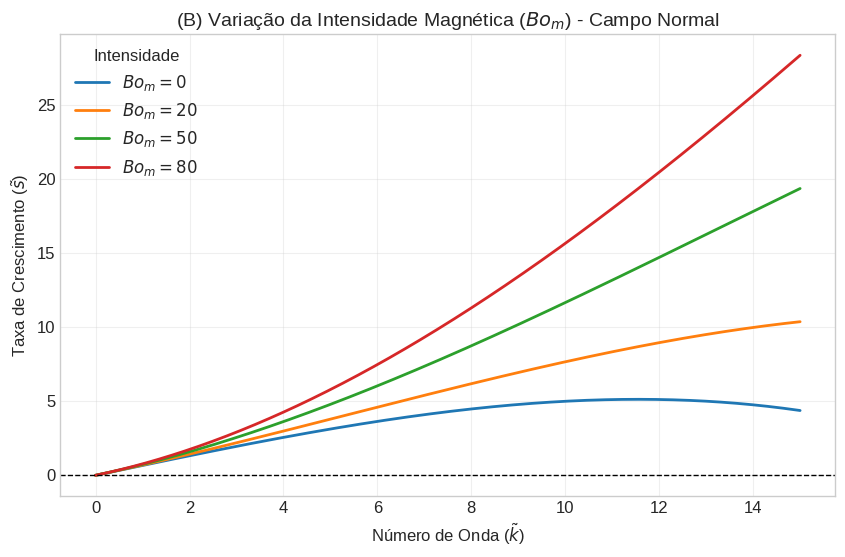

In [5]:
# --- CÉLULA 5: GRÁFICO B (INTENSIDADE Bo_m) ---

plt.figure(figsize=(10, 6))

# Valores de Bo_m para testar
bom_values = [0, 20, 50, 80] # De sem campo (0) a campo muito forte (80)
theta_fixo = 0 # Campo Normal (Maximiza o efeito)

for val_bom in bom_values:
    # Calcula s(k) variando apenas Bo_m
    s = relacao_dispersao(k_vals, R_base, Da_base, Ca_base, val_bom, Lambda_base, theta_fixo)

    # Plotagem
    plt.plot(k_vals, s, linewidth=2, label=f'$Bo_m = {val_bom}$')

# Linha de referência
plt.axhline(0, color='black', linewidth=1, linestyle='--')

# Decoração
plt.title(r'(B) Variação da Intensidade Magnética ($Bo_m$) - Campo Normal', fontsize=14)
plt.xlabel(r'Número de Onda ($\tilde{k}$)', fontsize=12)
plt.ylabel(r'Taxa de Crescimento ($\tilde{s}$)', fontsize=12)
plt.legend(title="Intensidade")
plt.grid(True, alpha=0.3)

plt.show()

Calculando mapa de estabilidade...


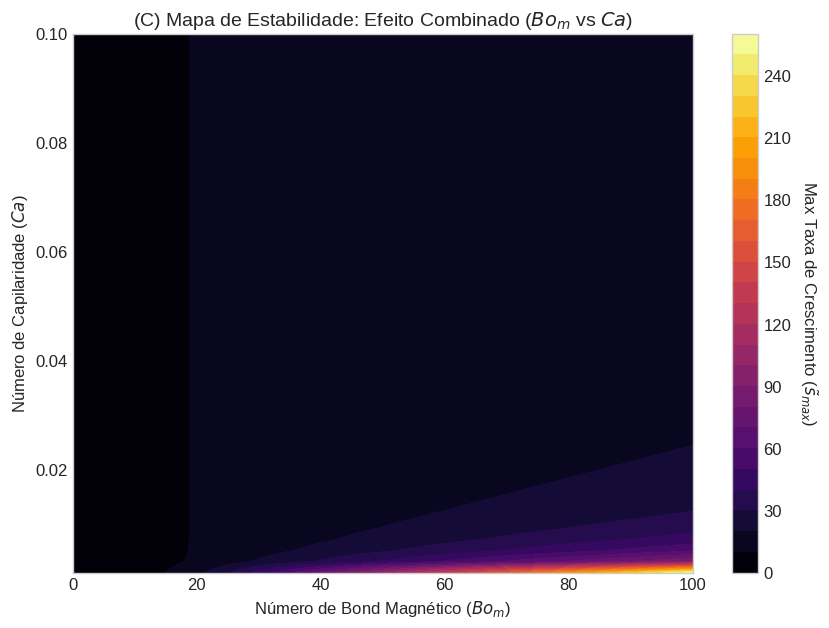

In [6]:
# --- CÉLULA 6: GRÁFICO C (MAPA DE ESTABILIDADE) ---

plt.figure(figsize=(10, 7))

# 1. Criar a malha (grid) de parâmetros
bom_grid = np.linspace(0, 100, 50)    # Eixo X: Intensidade Magnética
ca_grid = np.linspace(0.001, 0.1, 50) # Eixo Y: Capilaridade (Velocidade)
X, Y = np.meshgrid(bom_grid, ca_grid)
Z = np.zeros_like(X) # Matriz para guardar o resultado (s_max)

# 2. Loop sobre cada ponto da malha para calcular a estabilidade
# Isso pode levar alguns segundos dependendo da resolução
print("Calculando mapa de estabilidade...")
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        # Para cada par (Bo, Ca), gera a curva s(k) e pega o valor máximo
        s_curve = relacao_dispersao(k_vals, R_base, Da_base, Y[i,j], X[i,j], Lambda_base, 0)
        Z[i, j] = np.max(s_curve)

# 3. Plotagem do contorno preenchido
# cmap='inferno' ou 'magma' destaca bem valores altos
cp = plt.contourf(X, Y, Z, 25, cmap='inferno')
cbar = plt.colorbar(cp)
cbar.set_label(r'Max Taxa de Crescimento ($\tilde{s}_{max}$)', rotation=270, labelpad=20)

# Decoração
plt.title(r'(C) Mapa de Estabilidade: Efeito Combinado ($Bo_m$ vs $Ca$)', fontsize=14)
plt.xlabel(r'Número de Bond Magnético ($Bo_m$)', fontsize=12)
plt.ylabel(r'Número de Capilaridade ($Ca$)', fontsize=12)

plt.show()

<>:23: SyntaxWarning: invalid escape sequence '\c'
<>:32: SyntaxWarning: invalid escape sequence '\c'
<>:23: SyntaxWarning: invalid escape sequence '\c'
<>:32: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipython-input-160/2339042262.py:23: SyntaxWarning: invalid escape sequence '\c'
  label=f'Normal ($0^\circ$), k={k}')
/tmp/ipython-input-160/2339042262.py:32: SyntaxWarning: invalid escape sequence '\c'
  label=f'Tangencial ($90^\circ$), k={k}')


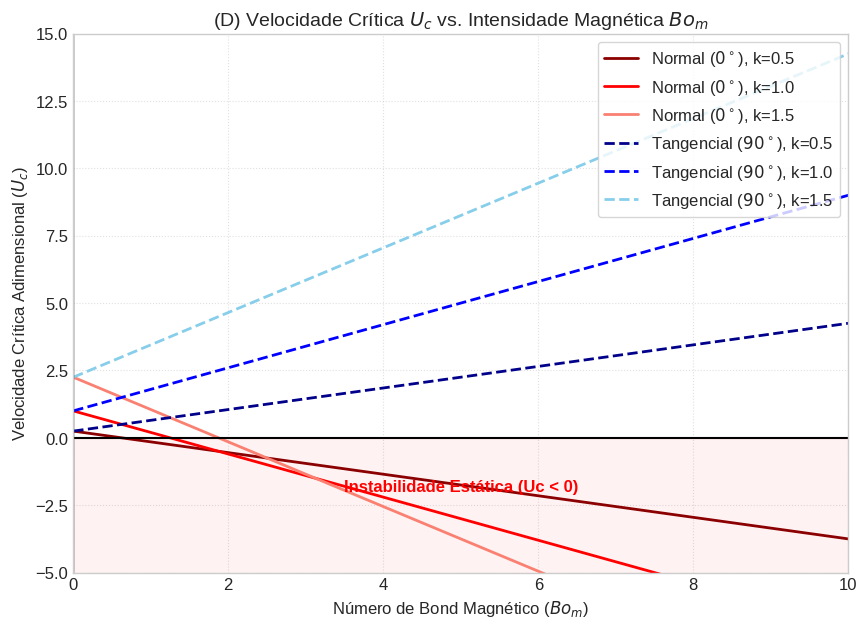

In [7]:
# --- CÉLULA 7: GRÁFICO D (VELOCIDADE CRÍTICA vs Bo_m) ---

plt.figure(figsize=(10, 7))

# Parâmetros dimensionais unitários (para análise qualitativa)
K_sim = 1.0
eta_diff_sim = 1.0
sigma_sim = 1.0

# Eixo X: Variação do Bo_m
bom_eixo_x = np.linspace(0, 10, 200)

# Modos de onda para analisar (comprimentos de onda diferentes)
k_modos = [0.5, 1.0, 1.5]

# --- CASO 1: CAMPO NORMAL (0 GRAUS) ---
# Linhas Sólidas em tons de vermelho
colors_normal = ['#8b0000', '#ff0000', '#fa8072'] # Vermelho escuro -> claro

for i, k in enumerate(k_modos):
    uc = velocidade_critica_bom(bom_eixo_x, k, sigma_sim, eta_diff_sim, K_sim, Lambda_base, 0)
    plt.plot(bom_eixo_x, uc, color=colors_normal[i], linewidth=2,
             label=f'Normal ($0^\circ$), k={k}')

# --- CASO 2: CAMPO TANGENCIAL (90 GRAUS) ---
# Linhas Tracejadas em tons de azul
colors_tang = ['#00008b', '#0000ff', '#87ceeb'] # Azul escuro -> claro

for i, k in enumerate(k_modos):
    uc = velocidade_critica_bom(bom_eixo_x, k, sigma_sim, eta_diff_sim, K_sim, Lambda_base, 90)
    plt.plot(bom_eixo_x, uc, color=colors_tang[i], linestyle='--', linewidth=2,
             label=f'Tangencial ($90^\circ$), k={k}')

# Linhas de referência dos eixos
plt.axhline(0, color='black', linewidth=1.5) # Eixo X
plt.axvline(0, color='black', linewidth=1)   # Eixo Y

# Regiões coloridas para facilitar interpretação
plt.fill_between(bom_eixo_x, -10, 0, color='red', alpha=0.05) # Instabilidade Estática
plt.text(5, -2, 'Instabilidade Estática (Uc < 0)', color='red', ha='center', fontweight='bold')

plt.title(r'(D) Velocidade Crítica $U_c$ vs. Intensidade Magnética $Bo_m$', fontsize=14)
plt.xlabel(r'Número de Bond Magnético ($Bo_m$)', fontsize=12)
plt.ylabel(r'Velocidade Crítica Adimensional ($U_c$)', fontsize=12)
plt.ylim(-5, 15)
plt.xlim(0, 10)
plt.legend(loc='upper right', frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()